8.0


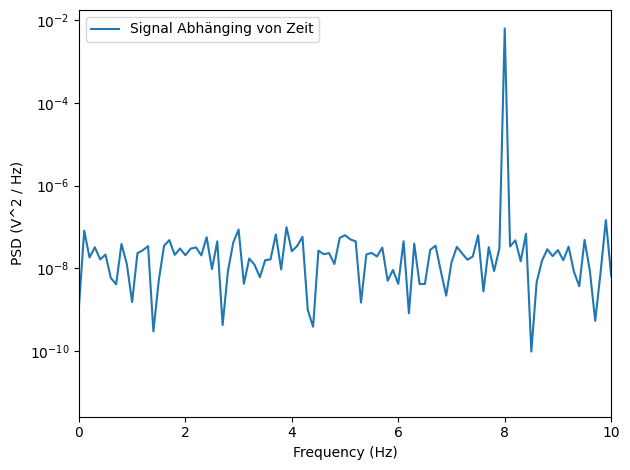

In [107]:
import numpy as np
from numpy.fft import fftfreq, fft, ifft
import matplotlib.pyplot as plt

data = np.loadtxt('seismic_test_dataset7.txt', skiprows=1, delimiter=',')

time_s = data[:,0]
signal_V = data[:,1]
sensor_noise_V = data[:,2]

# plt.plot(time_s, signal_V)

def plot_plot(*data_pairs, xlabel='x', ylabel='y', scale='linear', title='', xlim=None, ylim=None):
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    for pair in data_pairs:
        if len(pair) == 1:
            y, label = pair[0], ''
            x = np.arange(len(y))
        elif len(pair) == 2:
            y, label = pair[0], pair[1]
            x = np.arange(len(y))
        else:
            x, y, label = pair[0], pair[1], pair[2]
        yerr = pair[3] if len(pair) > 3 else None
        fmt = pair[4] if len(pair) > 4 else '-'
        ax.errorbar(x, y, yerr=yerr, fmt=fmt, capsize=5, label=label)
    
    if scale == 'logx':
        ax.set_xscale('log')
    elif scale == 'logy':
        ax.set_yscale('log')
    elif scale == 'loglog':
        ax.set_xscale('log')
        ax.set_yscale('log')
    
    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()

def compute_psd(signal, t, return_spectrum=False):
    dt = t[1] - t[0]
    N = len(t)
    frequency = fftfreq(N, d=dt)
    spectrum = fft(signal)
    psd = dt / N * np.abs(spectrum) ** 2
    mask = frequency >= 0
    if return_spectrum:
        return frequency[mask], psd[mask], spectrum
    return frequency[mask], psd[mask]

freq, psd = compute_psd(signal_V, time_s)

print(freq[np.argmax(psd)])

plot_plot(
    (freq, psd, 'Signal Abhänging von Zeit'),
    xlabel='Frequency (Hz)',
    ylabel='PSD (V^2 / Hz)',
    scale='logy',
    xlim=(0, 10)
)

In [108]:
print(np.var(signal_V))
print(np.var(sensor_noise_V))

print(np.var(signal_V) - np.var(sensor_noise_V))

0.0012724760448166426
2.5048033039491148e-05
0.0012474280117771514


In [109]:

cov_np = np.cov(signal_V, sensor_noise_V)[0, 1]

print(cov_np)

-2.4834940141162054e-06


In [110]:
waiting_time_s = np.loadtxt('earthquake_waiting_times7.txt', skiprows=1)

#print(waiting_time_s)

tau = np.mean(waiting_time_s)

def prob(tau, t):
    return 1 - np.exp(-t / tau)

print(prob(tau, 30) * 100)

55.3953411171735
